<a href="https://colab.research.google.com/github/KarenKhou/SmartCloset/blob/main/MDP_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
!nvidia-smi


Sat Mar 15 18:17:40 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**SETUP**

In [10]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.2/949.2 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [71]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.5/112.6 GB disk)


In [72]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo mode=checks

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/cfg/__init__.py", line 920, in entrypoint
    raise ValueError(f"Invalid 'mode={mode}'. Valid modes are {MODES}.\n{CLI_HELP_MSG}")
ValueError: Invalid 'mode=<module 'ultralytics.utils.checks' from '/usr/local/lib/python3.11/dist-packages/ultralytics/utils/checks.py'>'. Valid modes are frozenset({'benchmark', 'export', 'track', 'val', 'train', 'predict'}).

    Arguments received: ['yolo', 'mode=checks']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of frozenset({'segment', 'detect', 'classify', 'pose', 'obb'})
                MODE (required) is one of frozenset({'benchmark', 'export', 'track', 'val', 'train', 'predict'})
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' tha

In [11]:
pip install --upgrade ultralytics

# **Connecting to the Roboflow project to download the dataset**

In [15]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="AMVUobZbQn01XSn2xIwB")
project = rf.workspace("smartcloset").project("cloth_detection-j04oy-dmtn6")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


# **Find the path to our dataset and yaml file**

In [31]:
!ls /content/


cloth_detection-1  datasets  runs  sample_data	yolo11n.pt  yolov8m.pt


In [74]:
!ls /content/cloth_detection-1/

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [75]:
!cat /content/cloth_detection-1/data.yaml


names:
  - baseball cap
  - hoodie
  - jacket
  - pants
  - shirt
  - shorts
  - sneaker
  - sunglasses
  - sweatshirt
  - t-shirt
nc: 10
roboflow:
  license: CC BY 4.0
  project: cloth_detection-j04oy-dmtn6
  url: https://universe.roboflow.com/smartcloset/cloth_detection-j04oy-dmtn6/dataset/1
  version: 1
  workspace: smartcloset
test: /content/cloth_detection-1/test/images
train: /content/cloth_detection-1/train/images
val: /content/cloth_detection-1/valid/images


# Making sure that we are using **GPU**

In [3]:
import torch
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.device_count())  # Should be > 0

True
1


In [23]:
dataset = version.download("yolov8")
print(dataset.location)

/content/cloth_detection-1


# **Train YOLOv8 on clothes dataset**

In [51]:
!rm -rf /content/runs/

In [53]:
!yolo task=detect mode=train model=yolov8m.pt data="/content/cloth_detection-1/data.yaml" epochs=25 imgsz=640

Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/cloth_detection-1/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True,

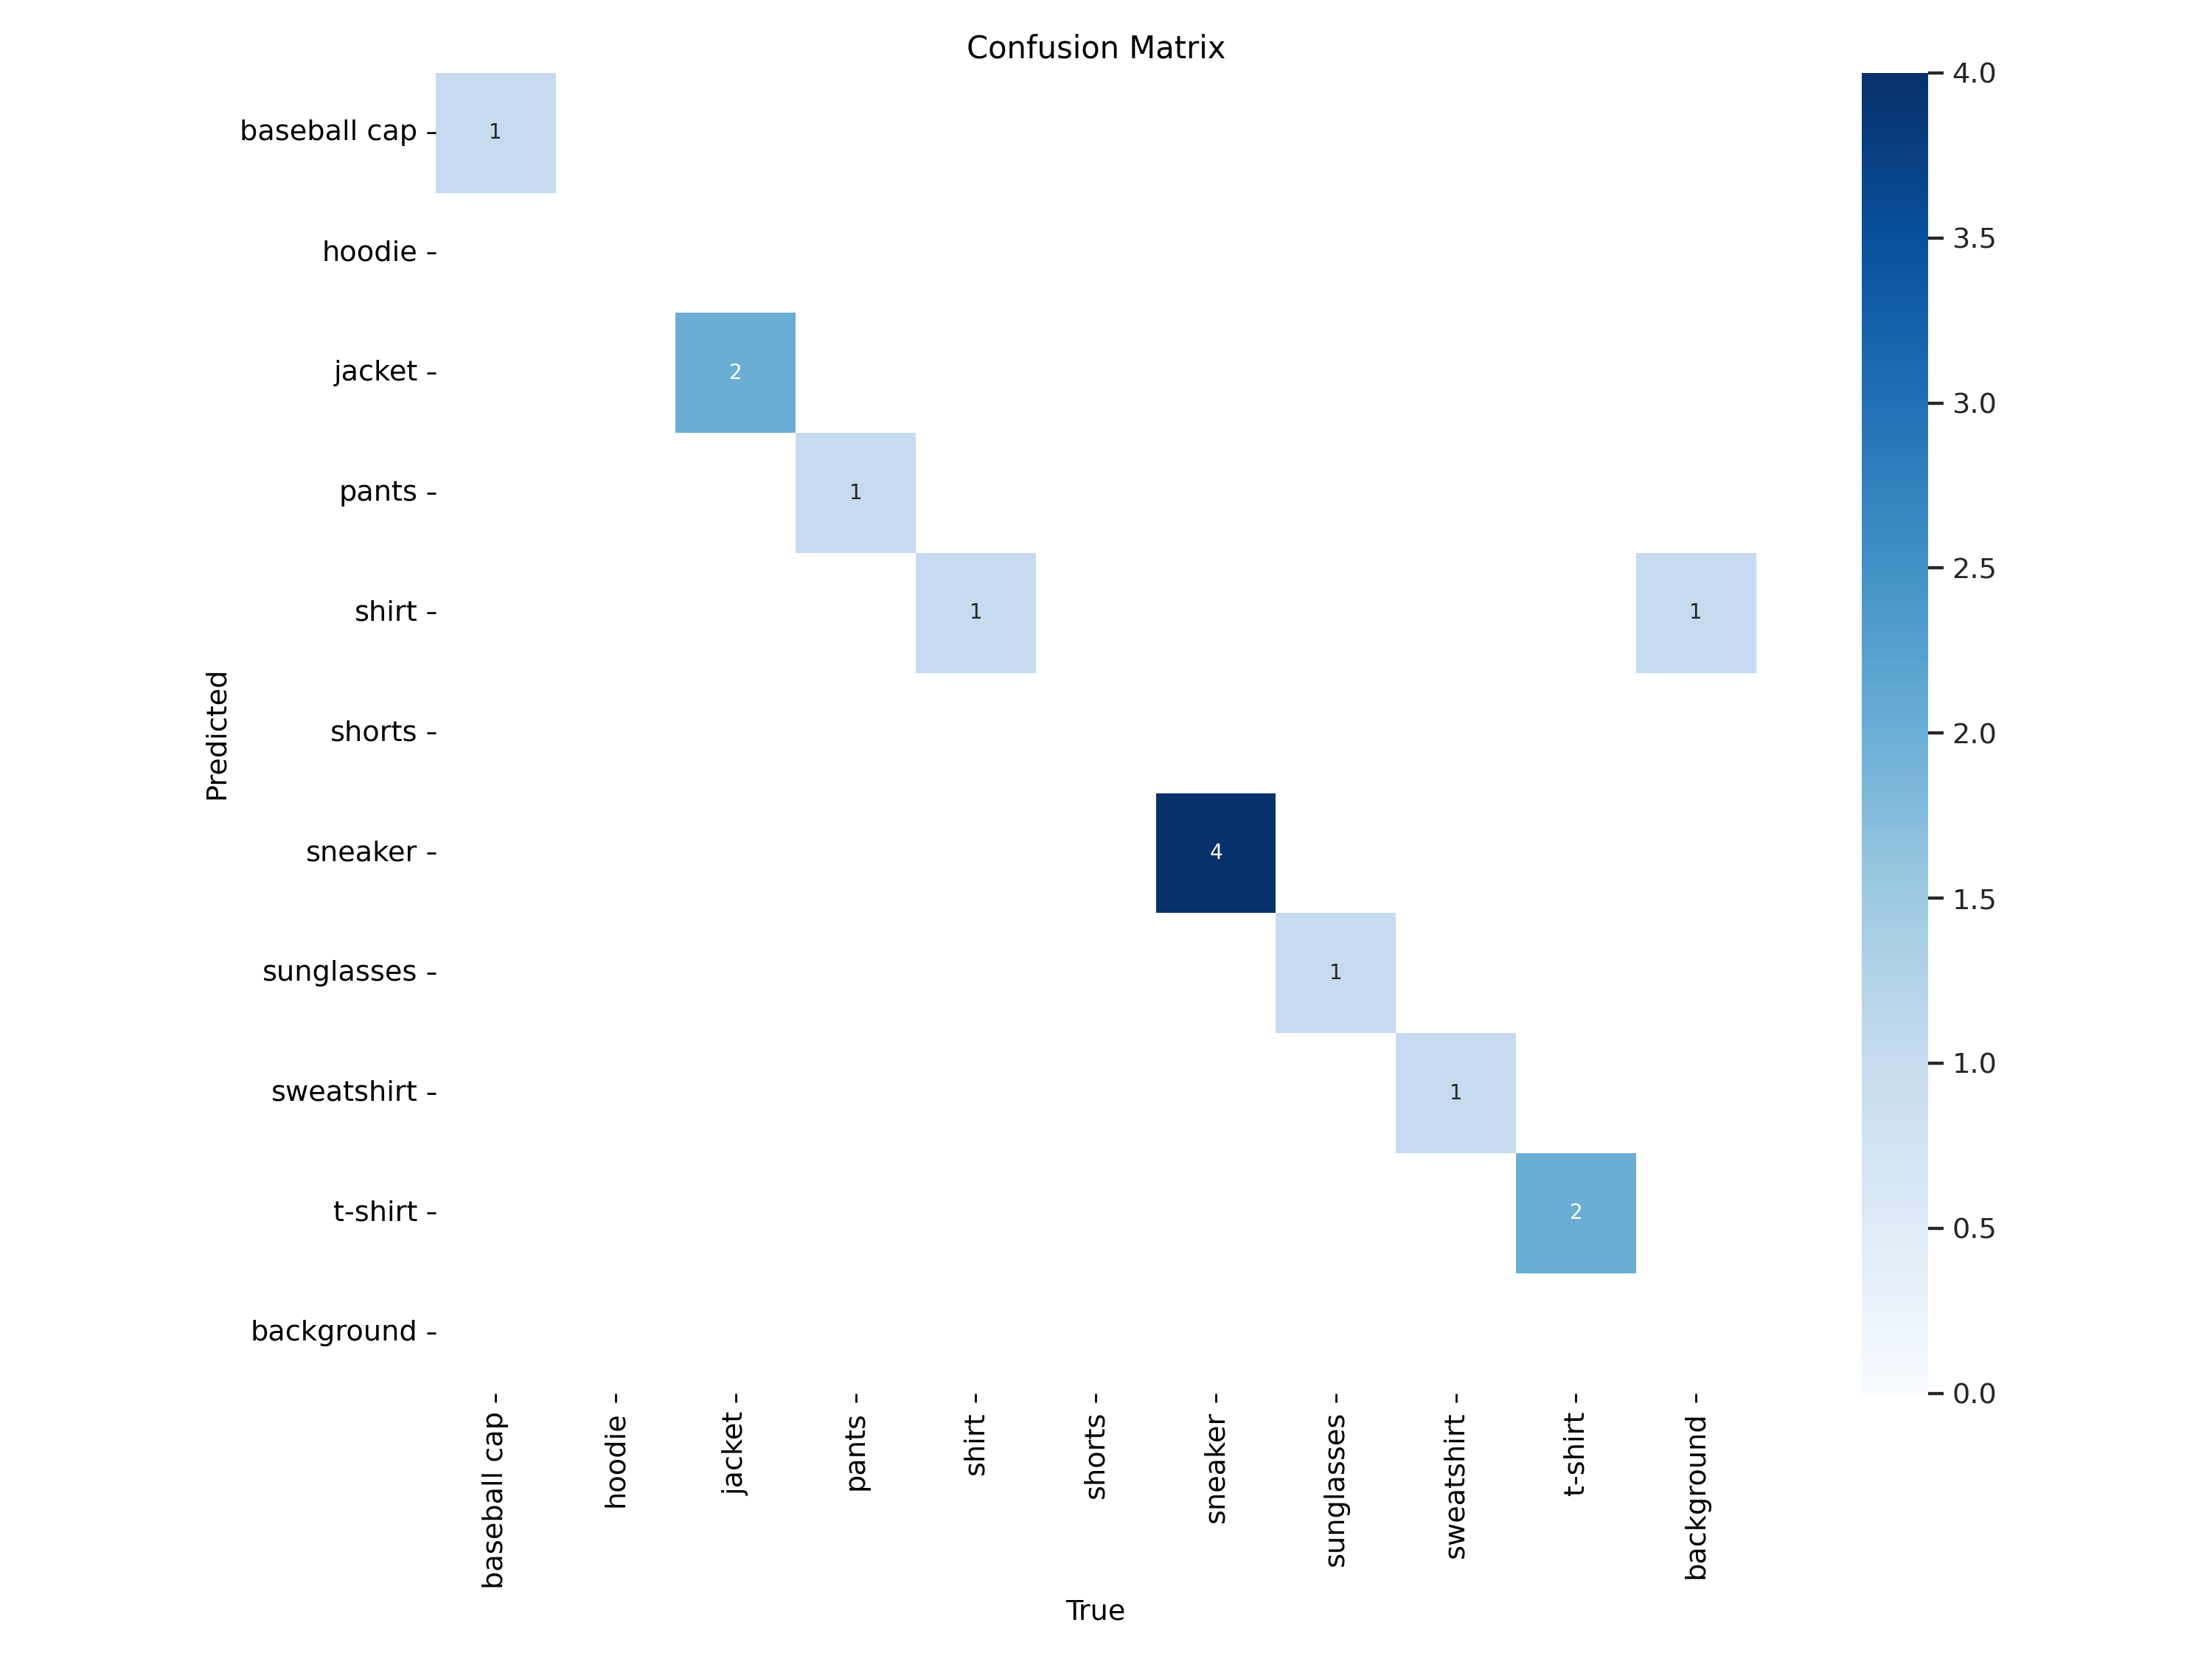

In [54]:
from IPython.display import Image
Image(filename=f'/content/runs/detect/train2/confusion_matrix.png', width=900)

# New Section

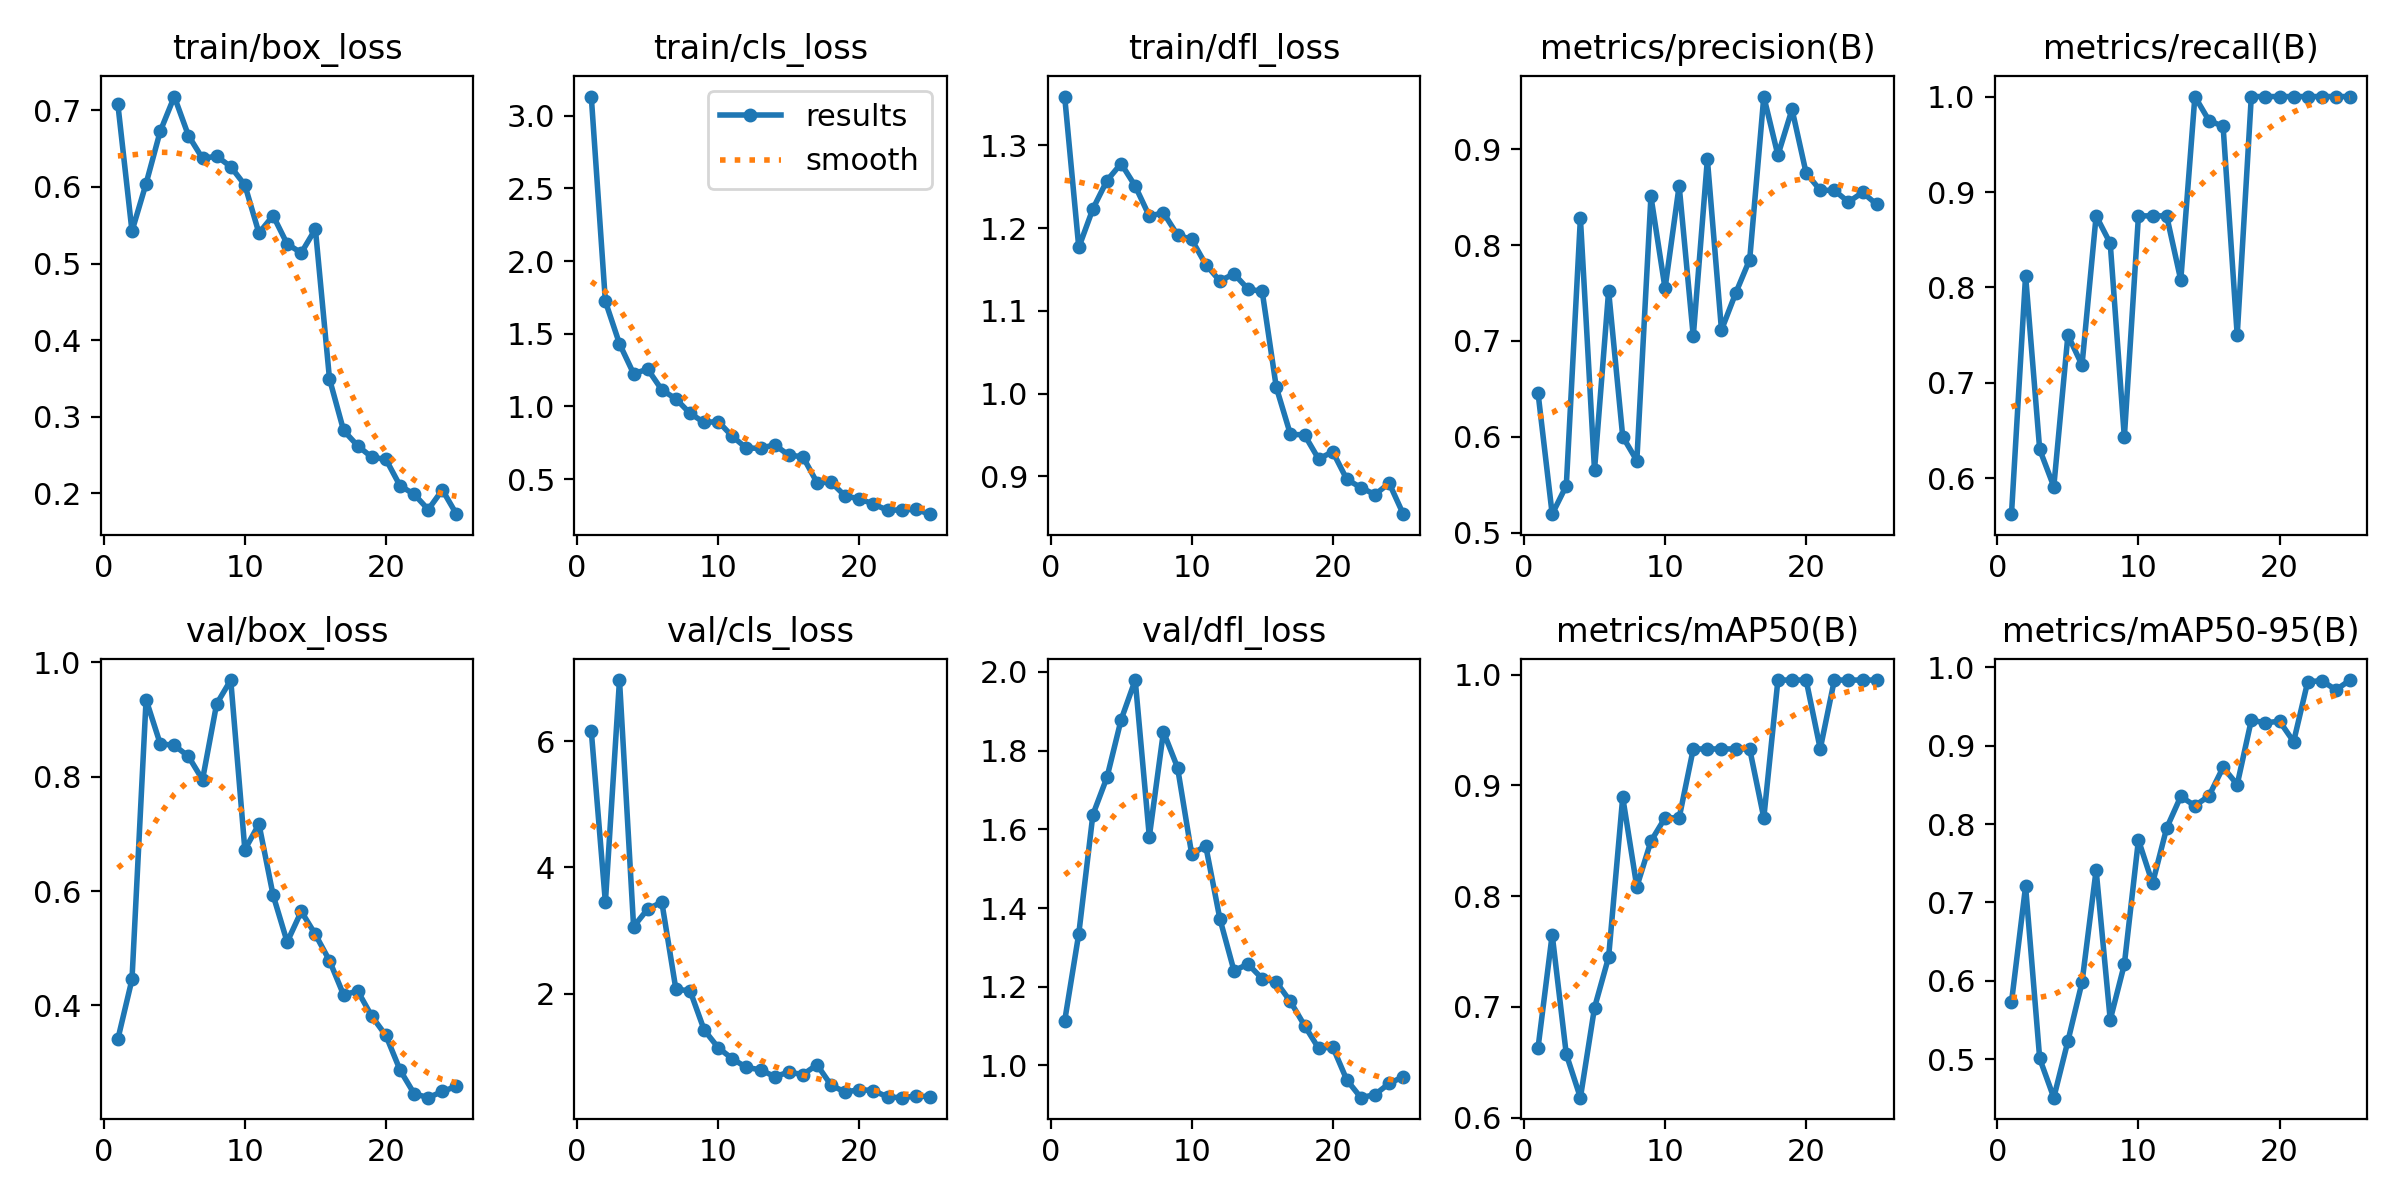

In [55]:
Image(filename=f'/content/runs/detect/train2/results.png', width=800)

In [57]:
!yolo task=detect mode=val model=/content/runs/detect/train2/weights/best.pt data="/content/cloth_detection-1/data.yaml"

Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
val: Scanning /content/cloth_detection-1/valid/labels.cache... 12 images, 1 backgrounds, 0 corrupt: 100% 12/12 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 1/1 [00:00<00:00,  1.49it/s]
                   all         12         13      0.842          1      0.995      0.984
          baseball cap          1          1      0.854          1      0.995      0.995
                jacket          2          2      0.915          1      0.995      0.949
                 pants          1          1      0.965          1      0.995      0.995
                 shirt          1          1       0.45          1      0.995      0.995
               sneaker          2          4      0.943          1      0.995       0.95
            sunglasses          1          1      

In [64]:
!yolo task=detect mode=predict model=/content/runs/detect/train2/weights/best.pt conf=0.25 source="/content/cloth_detection-1/test/images"

Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs

image 1/12 /content/cloth_detection-1/test/images/photo_2023-05-29-12-28-43_jpeg_jpg.rf.32d4f8b251cc9bdee7dc418ebe224356.jpg: 640x640 1 baseball cap, 37.1ms
image 2/12 /content/cloth_detection-1/test/images/photo_2023-05-29-12-28-47_jpeg_jpg.rf.1d3b5b5cab37859ff4fccb2293fde69e.jpg: 640x640 1 t-shirt, 37.1ms
image 3/12 /content/cloth_detection-1/test/images/photo_2023-05-29-12-28-54-1-_jpeg_jpg.rf.211b152b15a2327754193e79ae2a8777.jpg: 640x640 1 hoodie, 37.0ms
image 4/12 /content/cloth_detection-1/test/images/photo_2023-05-29-12-29-05_jpeg_jpg.rf.60aec94965dc0a2c5e9297efc0f39d24.jpg: 640x640 1 sweatshirt, 37.1ms
image 5/12 /content/cloth_detection-1/test/images/photo_2023-05-29-12-29-11_jpeg_jpg.rf.4072a9948acefeba176789af2610c770.jpg: 640x640 1 t-shirt, 32.4ms
image 6/12 /content/cloth_detection-1/test/images/photo_2023-05-2

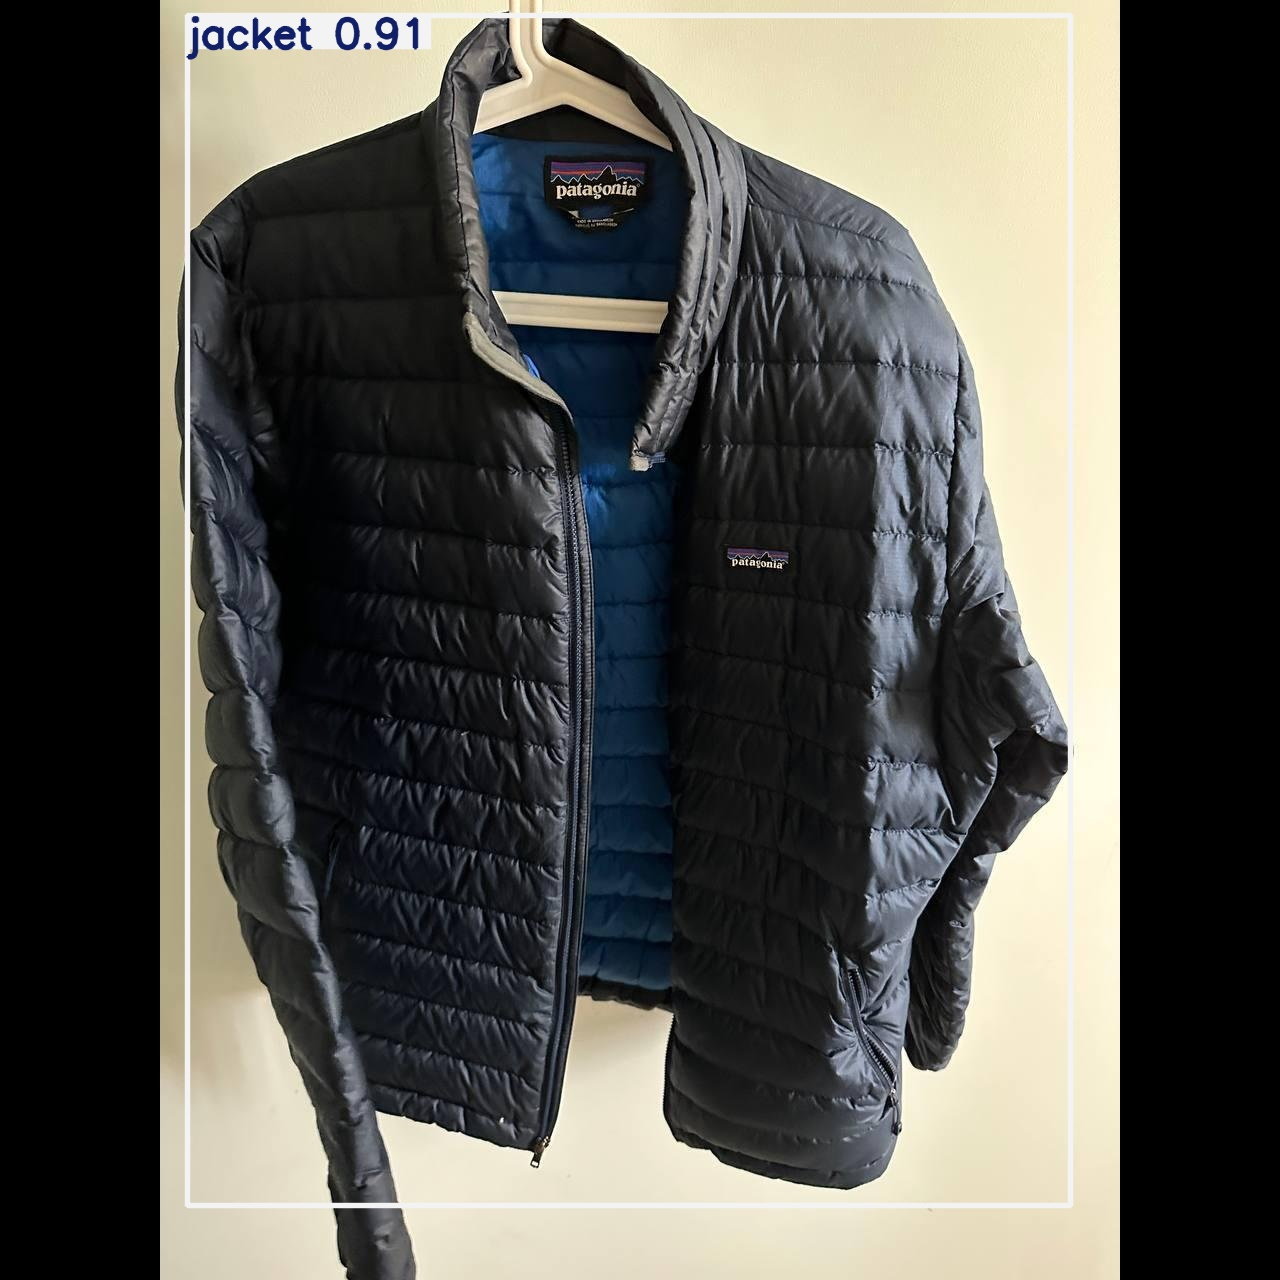

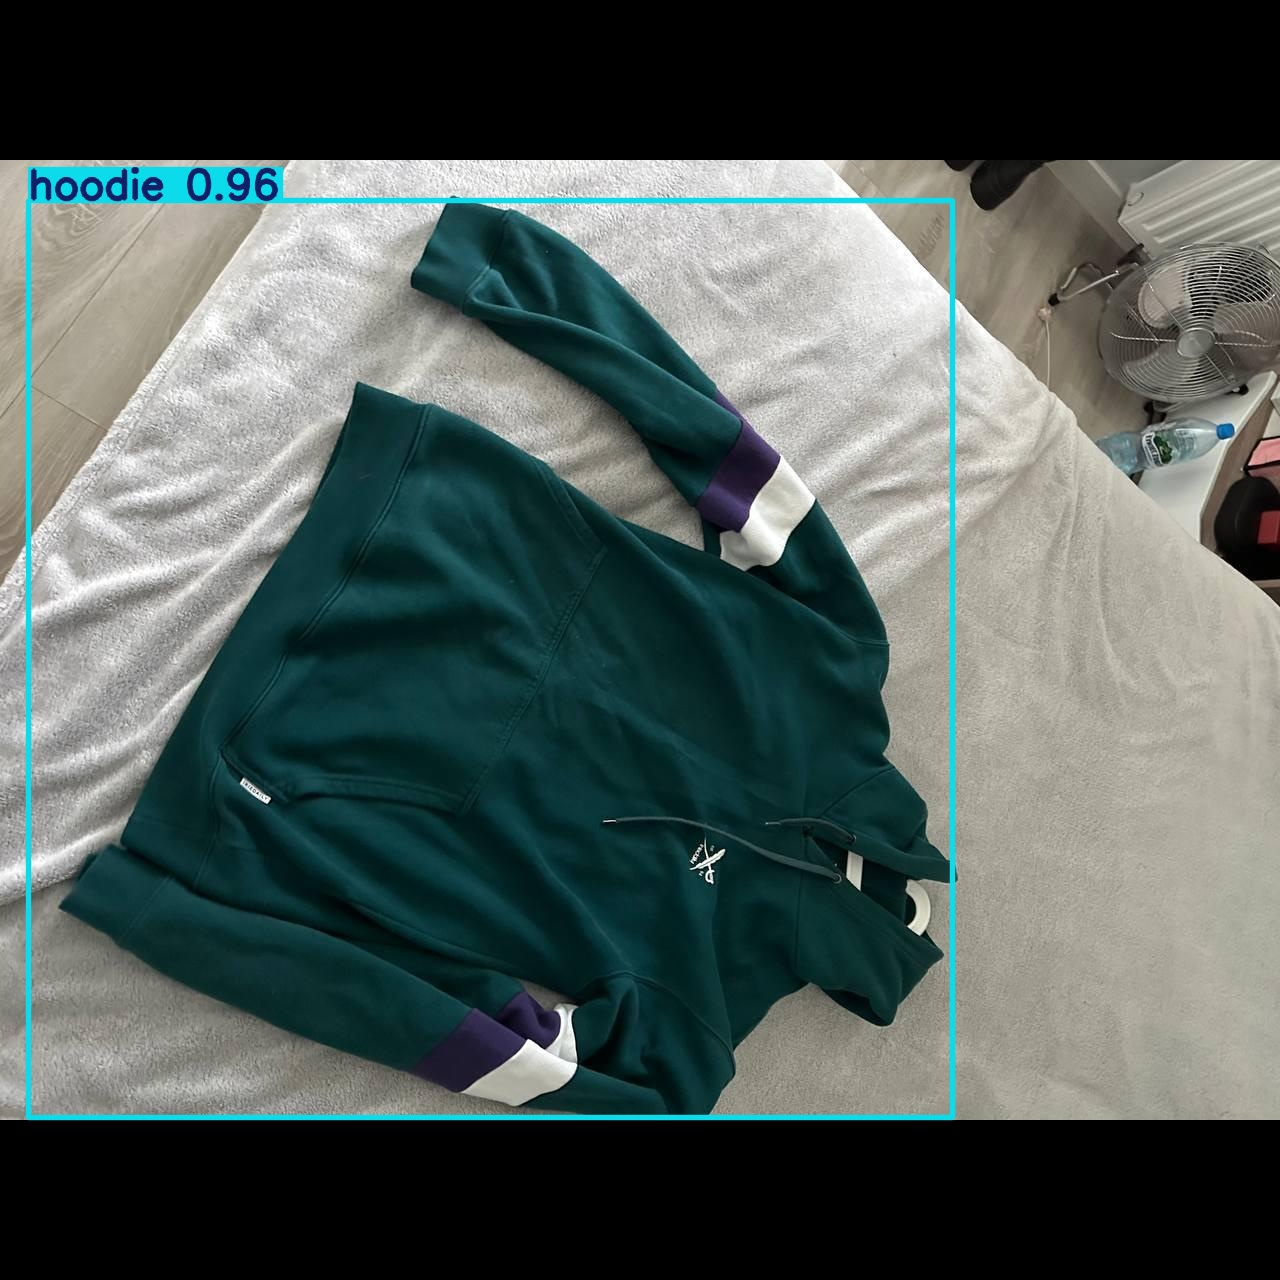

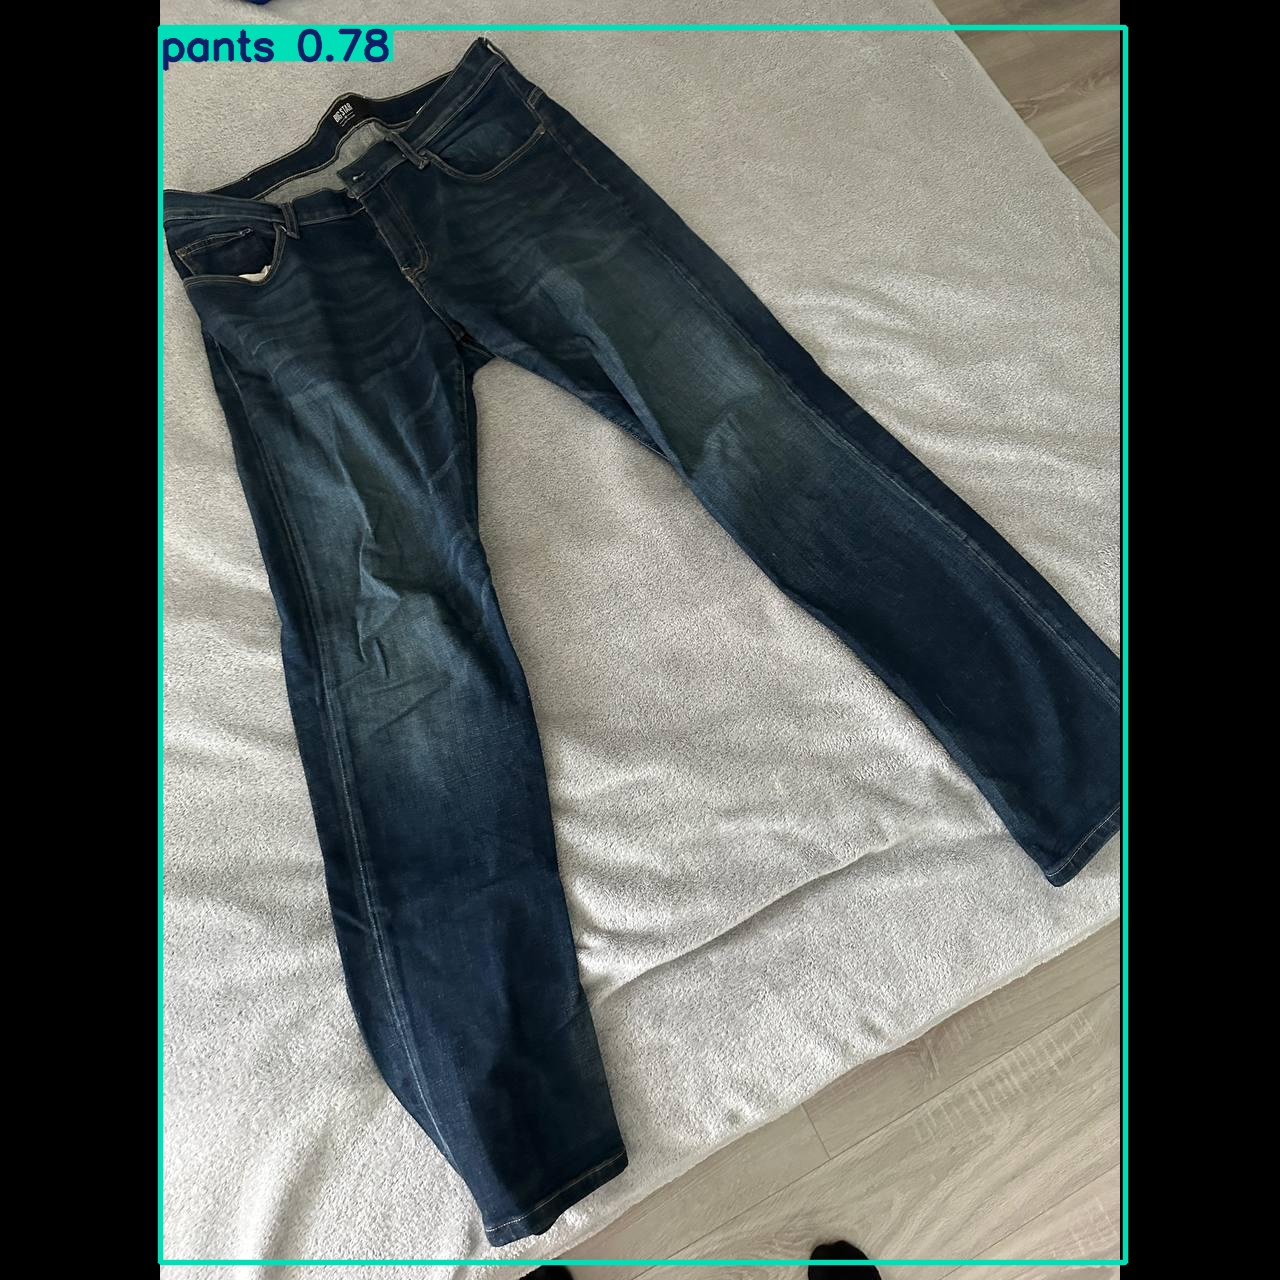

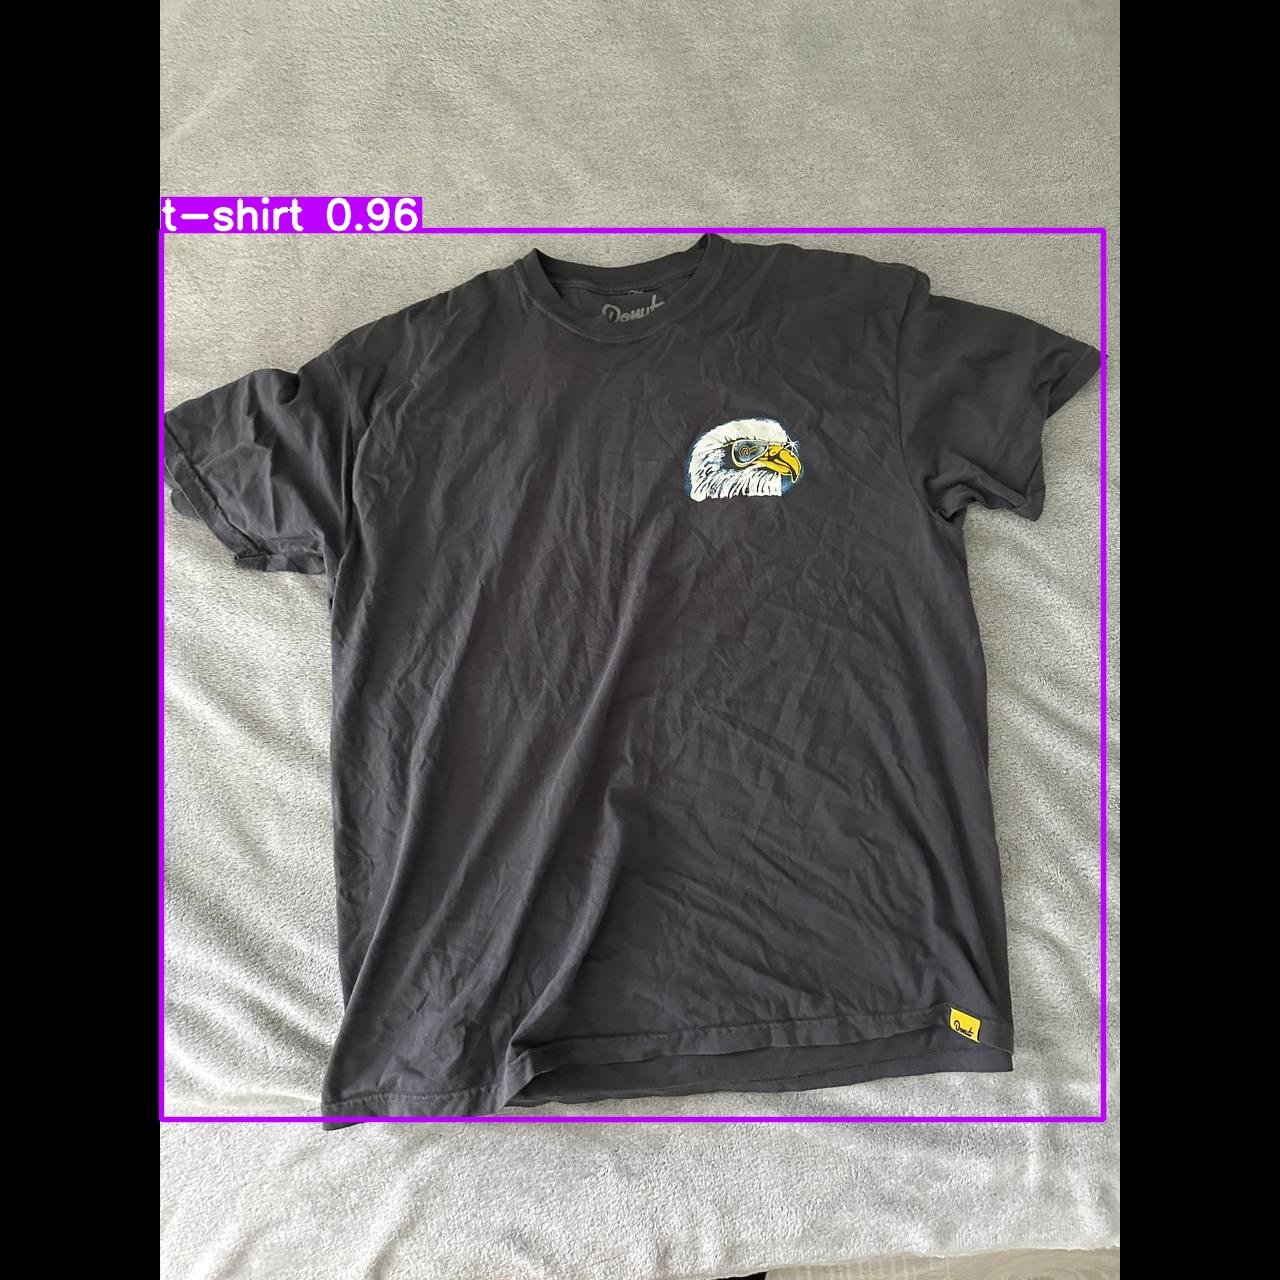

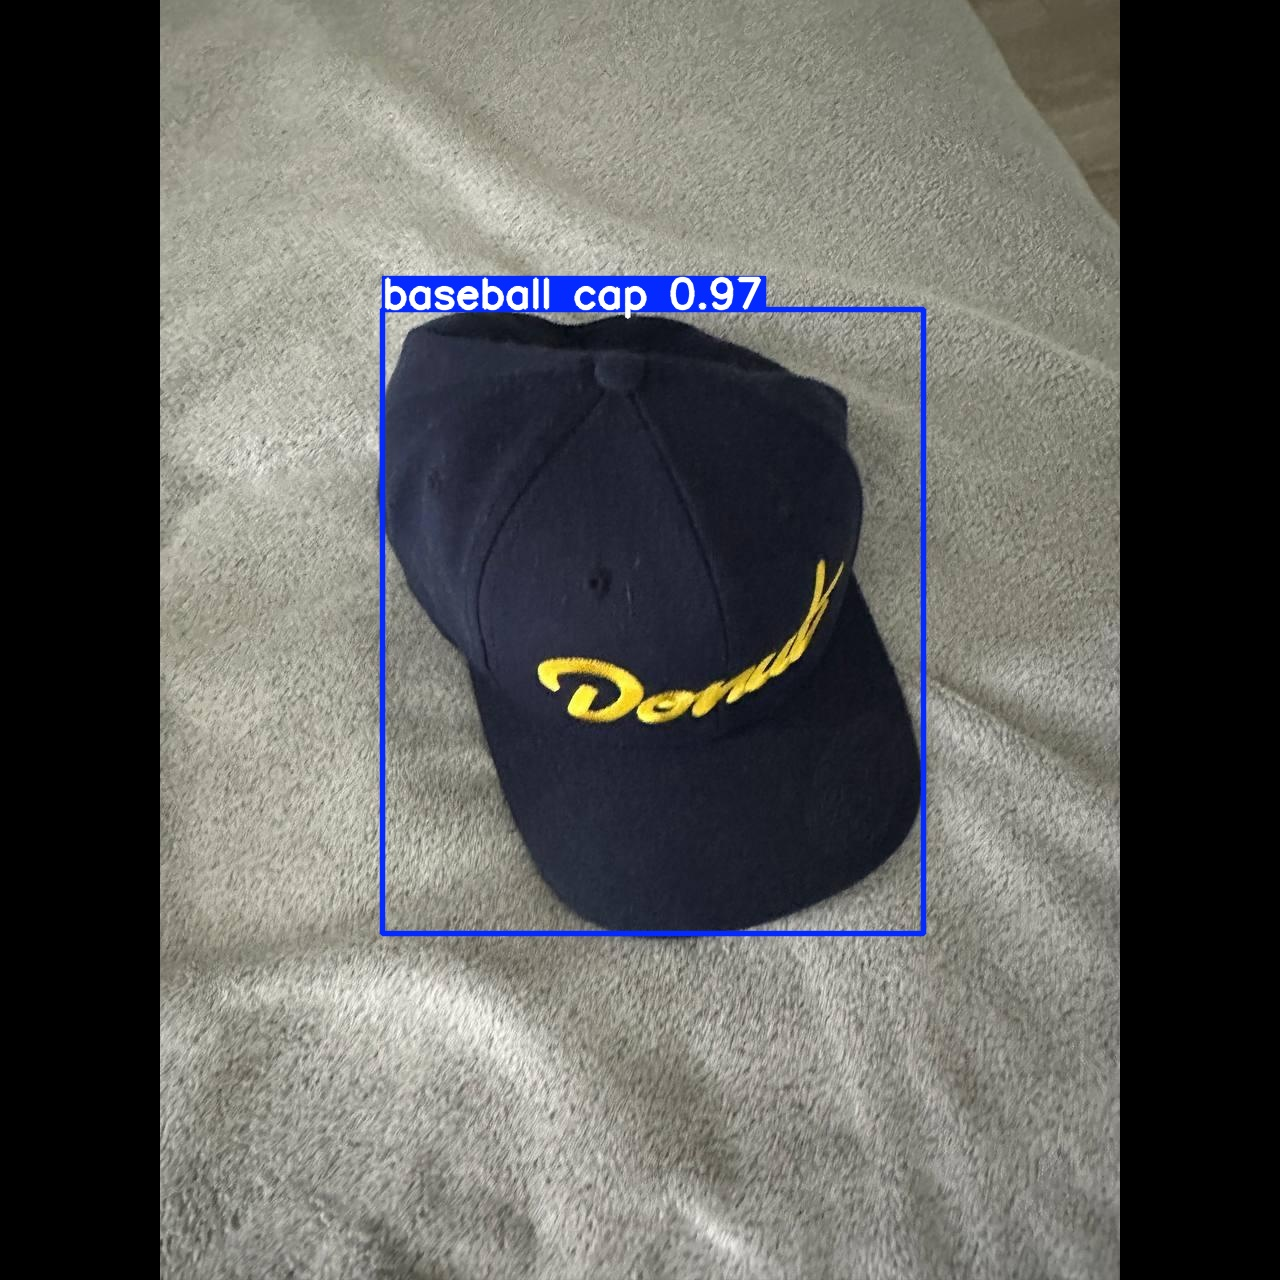

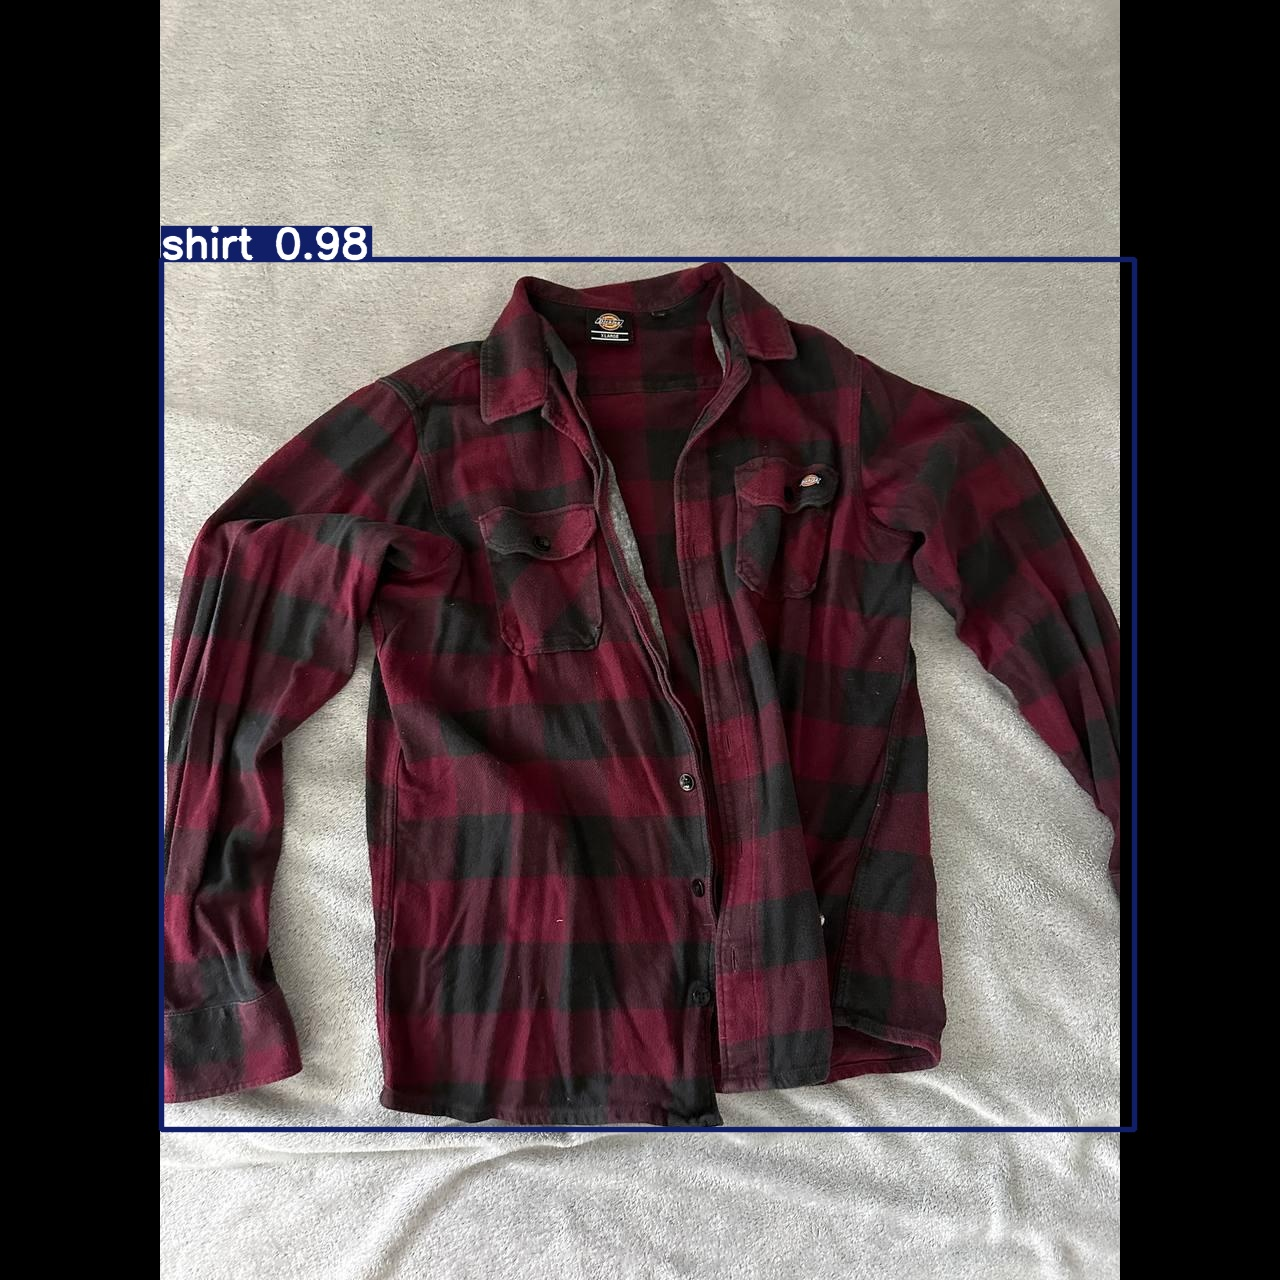

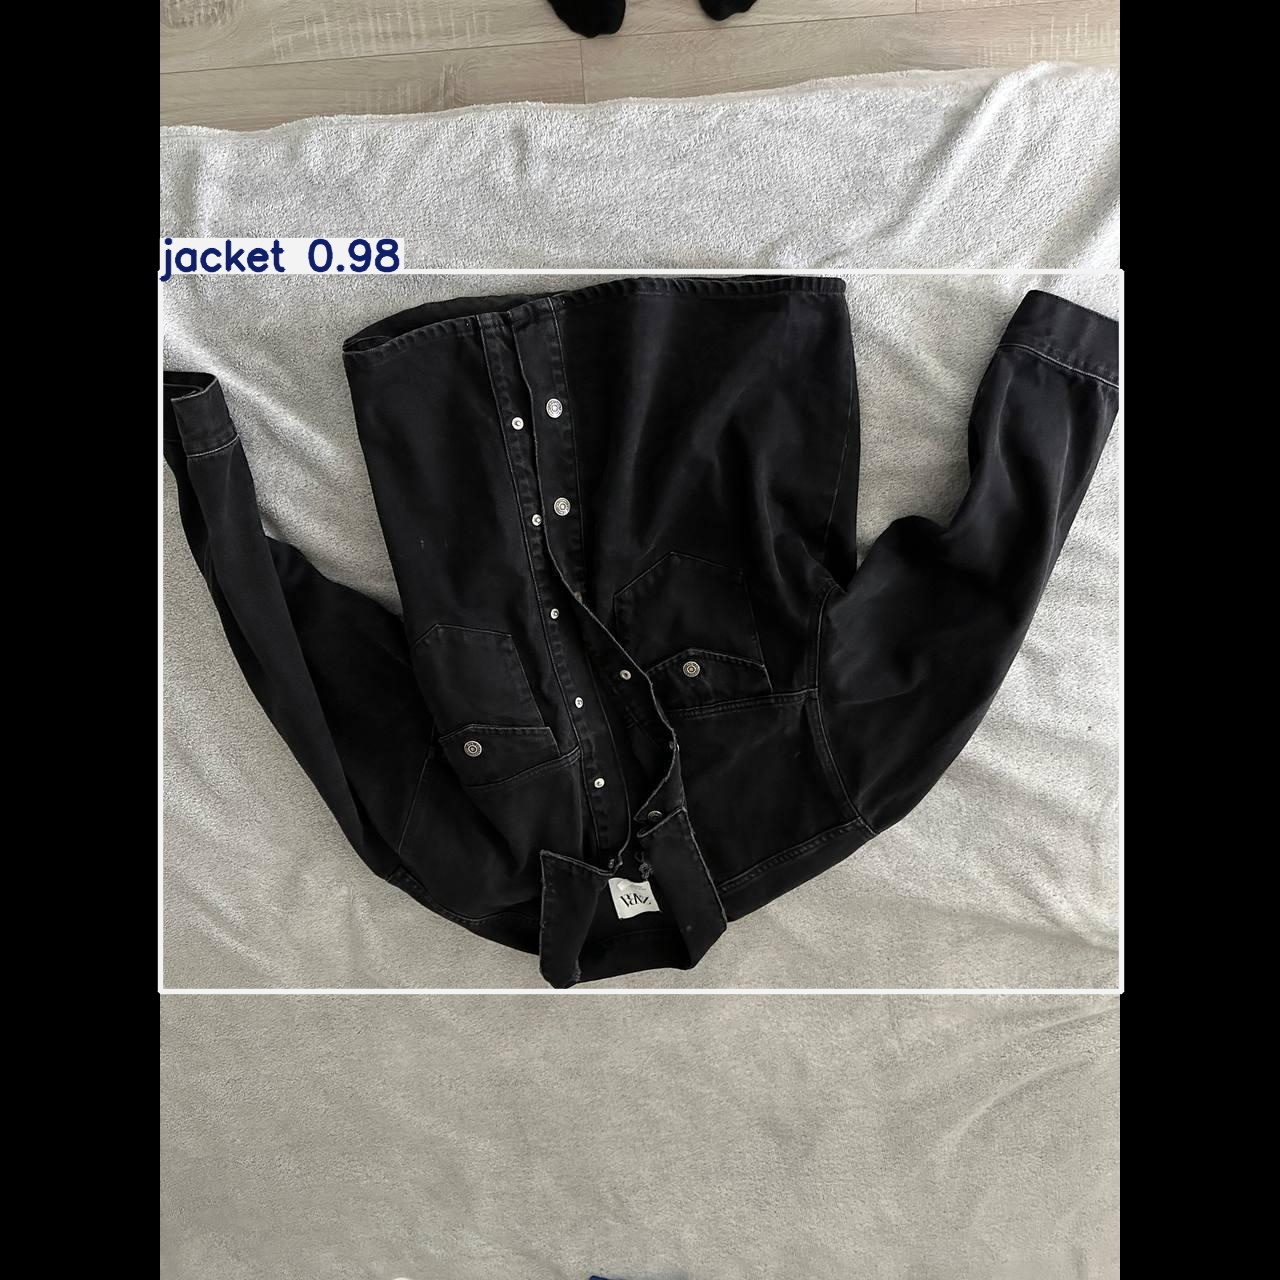

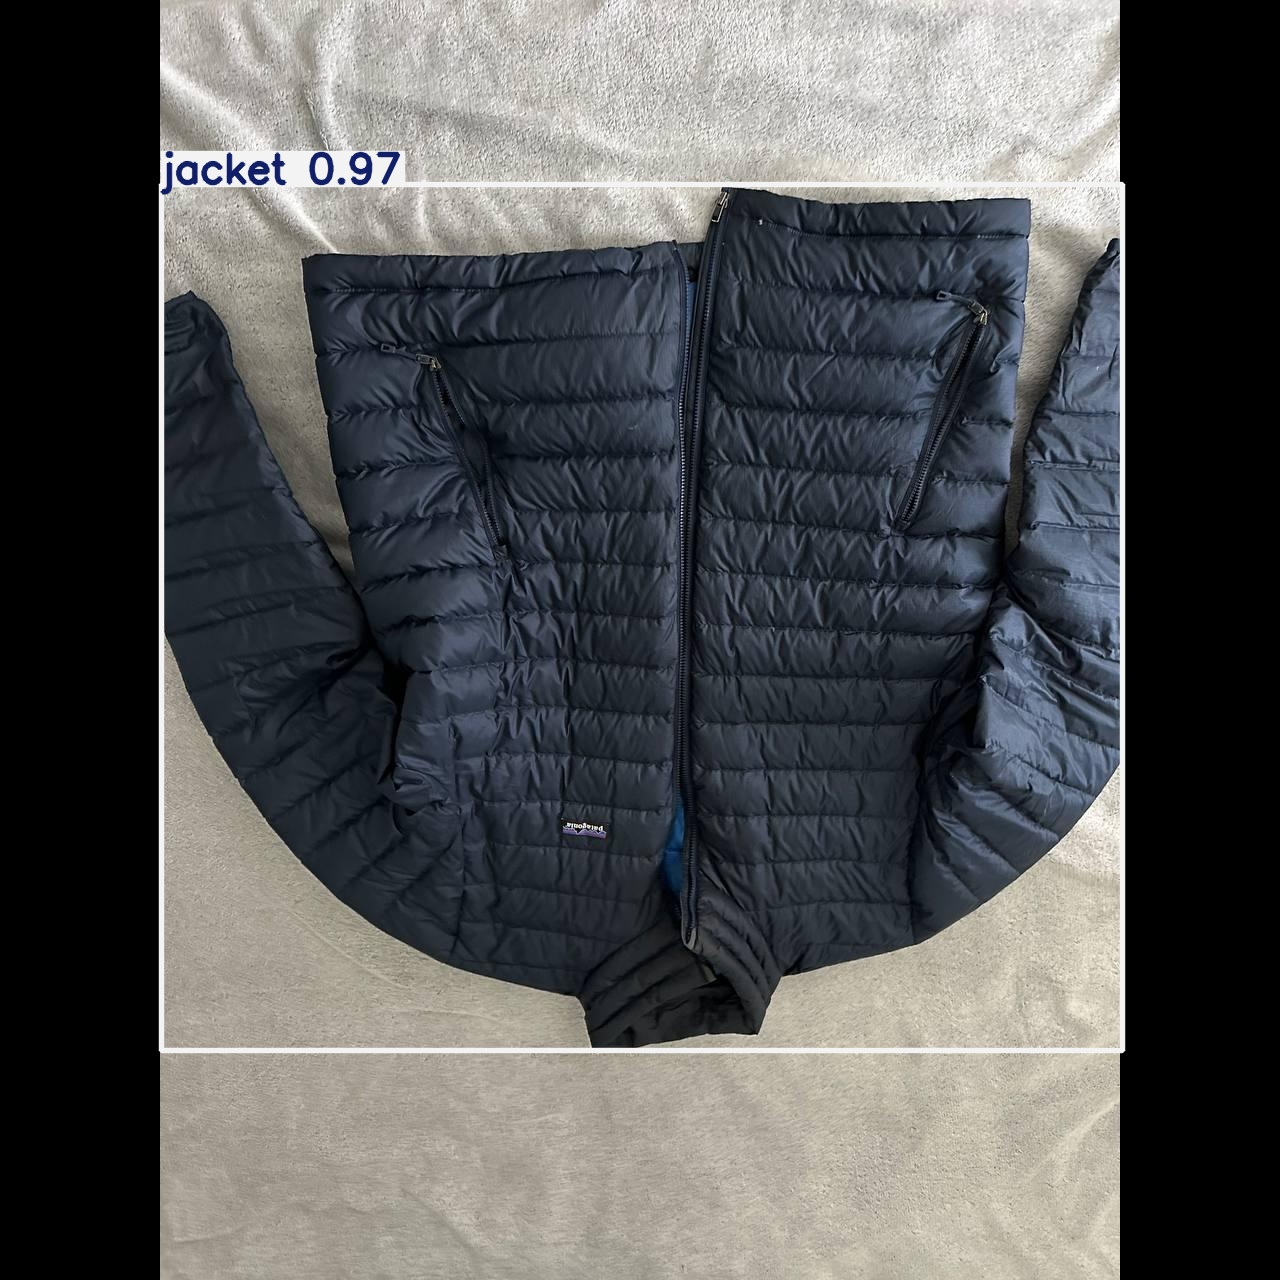

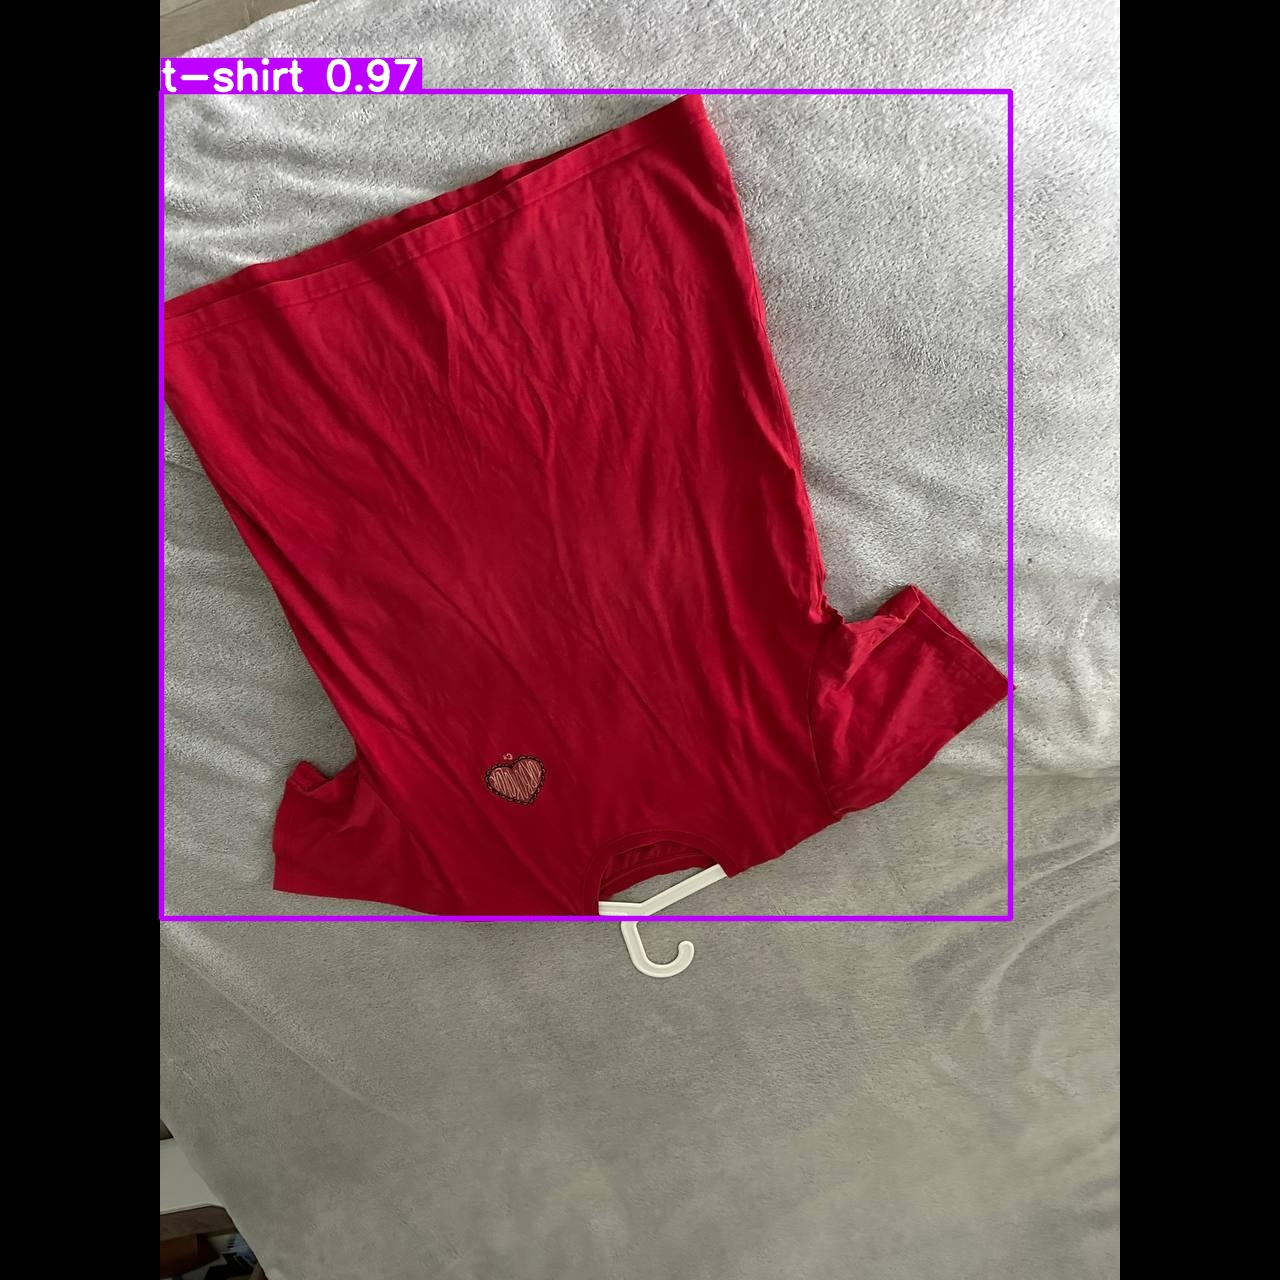

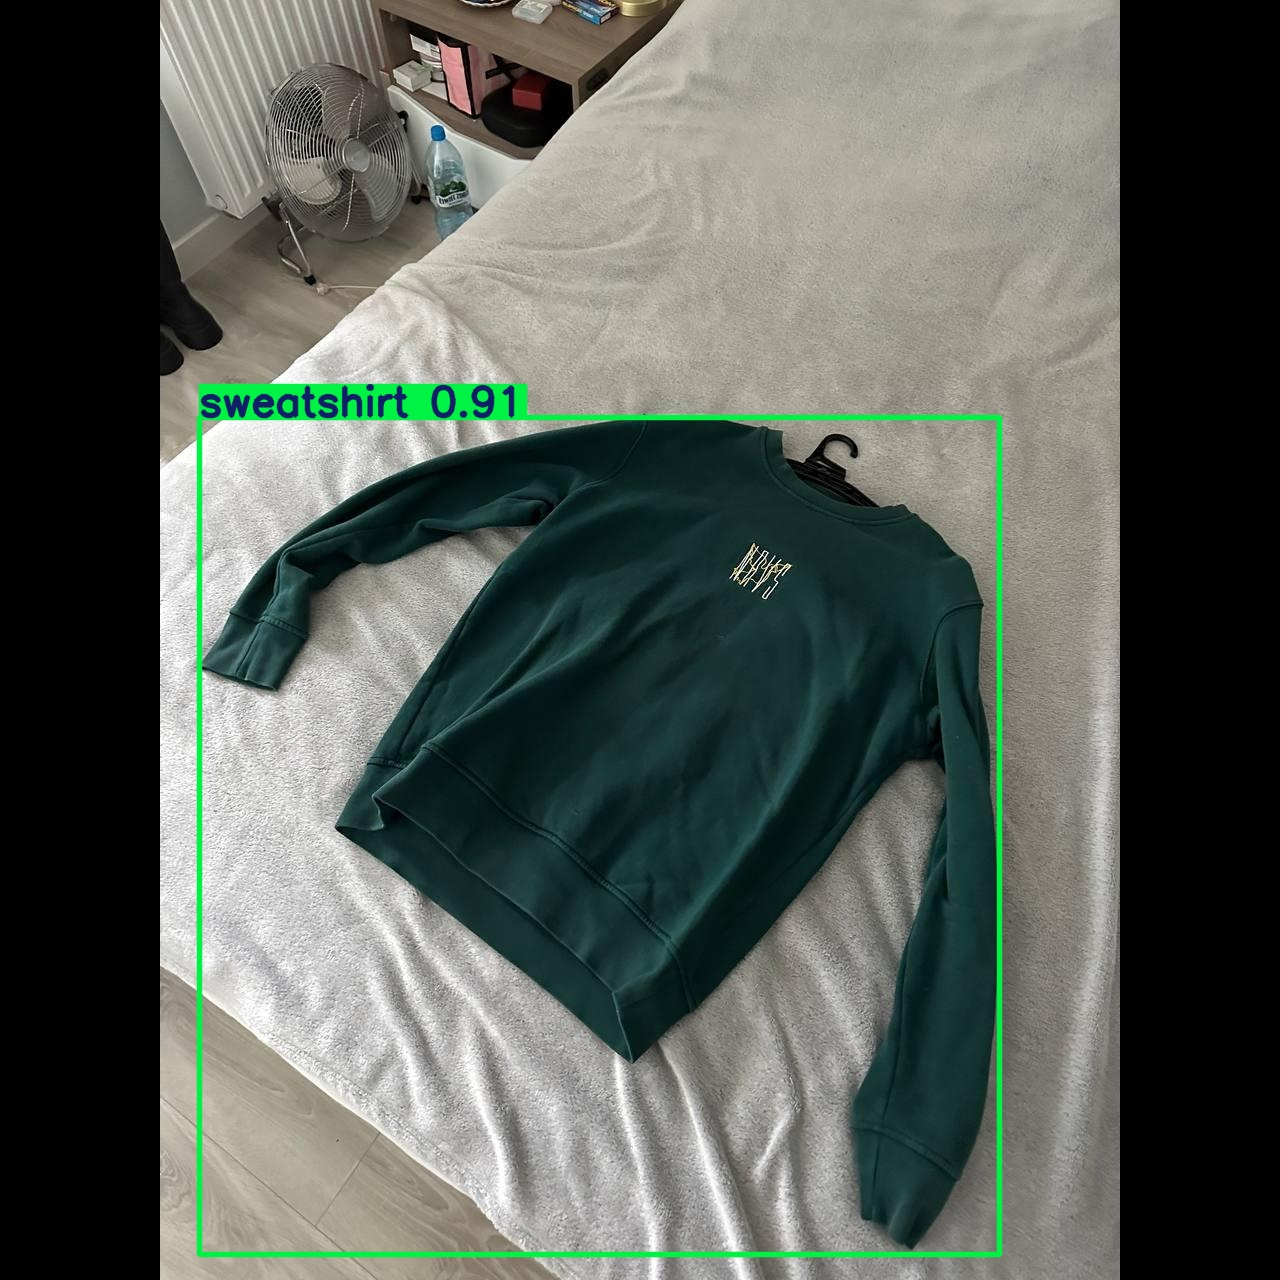

In [68]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/predict3/*.jpg')[:10]:
  display(Image(filename=image_path,height=600))
  print("\n")